# Multi-Objective Optimization for German Credit Risk
This notebook implements a Multi-Objective Optimization (MOO) pipeline to optimize a credit risk model (XGBoost) across three conflicting objectives:
1. **Accuracy (Maximize)**: Overall classification correctness.
2. **Fairness (Minimize DPD)**: Demographic Parity Difference between male and female groups.
3. **Expected Profit (Maximize)**: Based on an asymmetric cost matrix (+1 for correct approval/rejection, -5 for incorrect approval/default).

We implement and compare two MOO algorithms:
- **Optuna NSGA-II**
- **PyMOO NSGA-III**


In [1]:
%pip install -r /content/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.7 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement pywin32==310 (from versions: none)
ERROR: No matching distribution found for pywin32==310


In [3]:
pip install optuna plotly pymoo matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.4 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import optuna
import plotly.express as px
import plotly.graph_objects as go
import random
import os
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
os.makedirs("plots", exist_ok=True)

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Load data
DATA_PATH = '/content/german_credit_data_cleaned.csv'
#DATA_PATH = 'data/german_credit_data_cleaned.csv'
df = pd.read_csv(DATA_PATH)
y = df['Risk_good'].values
X_full = df.drop(columns=['Risk_good'])
sensitive = df['Sex_male'].values


## Custom Objective and Evaluation Functions
We use a custom objective function during XGBoost training to incorporate a fairness penalty (controlled by `alpha_fair`). The classification threshold is also a decision variable.


In [5]:
def make_custom_obj(sens_array, alpha_fair=0.5, fp_weight=1.0):
    '''Custom XGBoost objective combining log-loss and fairness penalty.'''
    def custom_obj(preds, dmatrix):
        labels = dmatrix.get_label()
        preds_prob = 1.0 / (1.0 + np.exp(-preds))

        # Apply asymmetric weight to False Positives (where label == 0)
        weights = np.where(labels == 0, fp_weight, 1.0)

        # Weighted Log-loss gradients
        grad_log = (preds_prob - labels) * weights
        hess_log = preds_prob * (1.0 - preds_prob) * weights

        # Fairness gradients (Demographic Parity)
        mask_p = (sens_array == 1)
        mask_u = (sens_array == 0)
        n_p, n_u = mask_p.sum(), mask_u.sum()

        mean_p = preds_prob[mask_p].mean() if n_p > 0 else 0
        mean_u = preds_prob[mask_u].mean() if n_u > 0 else 0
        diff = mean_p - mean_u
        sign = np.sign(diff)

        sigmoid_deriv = preds_prob * (1.0 - preds_prob)
        grad_fair = np.zeros_like(preds)

        if n_p > 0: grad_fair[mask_p] = sign * (1.0 / n_p) * sigmoid_deriv[mask_p]
        if n_u > 0: grad_fair[mask_u] = -sign * (1.0 / n_u) * sigmoid_deriv[mask_u]

        hess_fair = np.zeros_like(preds) # simplified

        grad = (1 - alpha_fair) * grad_log + alpha_fair * grad_fair
        hess = (1 - alpha_fair) * hess_log + alpha_fair * hess_fair
        return grad, hess
    return custom_obj

def evaluate_model(params, alpha_fair, threshold, fp_weight=1.0, seed=GLOBAL_SEED):
    '''Evaluates a configuration using 3-fold CV. Returns (accuracy, dpd, profit).'''
    kf = KFold(n_splits=3, shuffle=True, random_state=seed)
    acc_scores, dpd_scores, profit_scores = [], [], []

    for train_idx, val_idx in kf.split(X_full):
        X_train = X_full.iloc[train_idx].drop(columns=['Sex_male']).values
        y_train, sens_train = y[train_idx], sensitive[train_idx]

        X_val = X_full.iloc[val_idx].drop(columns=['Sex_male']).values
        y_val, sens_val = y[val_idx], sensitive[val_idx]

        train_obj = make_custom_obj(sens_train, alpha_fair=alpha_fair, fp_weight=fp_weight)
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)

        bst = xgb.train(
            params, dtrain, num_boost_round=100, obj=train_obj,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=10, verbose_eval=False
        )

        pred_prob = bst.predict(dval)
        pred = (pred_prob > threshold).astype(int)

        # 1. Accuracy
        acc = accuracy_score(y_val, pred)

        # 2. Fairness (DPD)
        dpd = abs(pred[sens_val == 1].mean() - pred[sens_val == 0].mean())

        # 3. Expected Profit
        # Cost matrix: True Positive (+1), True Negative (+1), False Positive/Default (-5), False Negative (0)
        profit = 0
        for i in range(len(y_val)):
            if y_val[i] == 1 and pred[i] == 1: profit += 1 # Good loan approved
            elif y_val[i] == 0 and pred[i] == 0: profit += 1 # Bad loan rejected
            elif y_val[i] == 0 and pred[i] == 1: profit -= 5 # Bad loan approved (DEFAULT)
            # Good loan rejected = 0 (missed opportunity)

        avg_profit = profit / len(y_val)

        acc_scores.append(acc)
        dpd_scores.append(dpd)
        profit_scores.append(avg_profit)

    return np.mean(acc_scores), np.mean(dpd_scores), np.mean(profit_scores)


## Algorithm 1: Optuna NSGA-II
We use Optuna's `NSGAIISampler` to optimize the 3 objectives over 200 trials.


In [6]:
def optuna_objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 7)
    eta = trial.suggest_float('eta', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)

    alpha_fair = trial.suggest_float('alpha_fair', 0.0, 1.0)
    threshold = trial.suggest_float('threshold', 0.3, 0.7)
    fp_weight = trial.suggest_float('fp_weight', 1.0, 10.0)

    params = {
        'max_depth': max_depth,
        'eta': eta,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'verbosity': 0,
        'seed': GLOBAL_SEED + trial.number
    }

    acc, dpd, profit = evaluate_model(params, alpha_fair, threshold, fp_weight)

    trial.set_user_attr('params', params)
    trial.set_user_attr('alpha_fair', alpha_fair)
    trial.set_user_attr('threshold', threshold)
    trial.set_user_attr('fp_weight', fp_weight)

    # Optuna maximizes accuracy, minimizes DPD, maximizes profit
    return acc, dpd, profit

# Run Optuna Study
sampler = optuna.samplers.NSGAIISampler(seed=GLOBAL_SEED)
study = optuna.create_study(directions=['maximize', 'minimize', 'maximize'], sampler=sampler)
study.optimize(optuna_objective, n_trials=200, show_progress_bar=True)

# Extract Pareto front
optuna_results = []
for trial in study.best_trials:
    optuna_results.append({
        'Algorithm': 'Optuna NSGA-II',
        'Accuracy': trial.values[0],
        'DPD': trial.values[1],
        'Profit': trial.values[2],
        'alpha_fair': trial.user_attrs['alpha_fair'],
        'threshold': trial.user_attrs['threshold'],
        'fp_weight': trial.user_attrs['fp_weight']
    })
df_optuna = pd.DataFrame(optuna_results)
print(f"Optuna found {len(df_optuna)} Pareto-optimal solutions.")


[I 2026-04-28 17:59:38,282] A new study created in memory with name: no-name-39d98bc1-015e-4ab5-95d8-b423f2bece04


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-28 17:59:41,873] Trial 0 finished with values: [0.6721563077262408, 0.08915625162567971, 0.4507632500390586] and parameters: {'max_depth': 4, 'eta': 0.28570714885887566, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'alpha_fair': 0.15601864044243652, 'threshold': 0.362397808134481, 'fp_weight': 1.5227525095137953}.
[I 2026-04-28 17:59:42,753] Trial 1 finished with values: [0.5000061268315397, 0.0, 0.5000061268315397] and parameters: {'max_depth': 7, 'eta': 0.18432335340553055, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'alpha_fair': 0.9699098521619943, 'threshold': 0.6329770563201687, 'fp_weight': 2.9110519961044856}.
[I 2026-04-28 17:59:43,339] Trial 2 finished with values: [0.5257097168484804, 0.016399730731486678, 0.514995420193424] and parameters: {'max_depth': 3, 'eta': 0.06318730785749581, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951, 'alpha_fair': 0.43194501864211576, 'threshold': 0.4164

## Algorithm 2: PyMOO NSGA-III
We define an `ElementwiseProblem` for PyMOO and run NSGA-III with Das-Dennis reference directions.


In [7]:
class CreditRiskProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(n_var=7, n_obj=3, n_ieq_constr=0,
                         xl=np.array([3, 0.01, 0.6, 0.6, 0.0, 0.3, 1.0]),
                         xu=np.array([7, 0.3, 1.0, 1.0, 1.0, 0.7, 10.0]))

    def _evaluate(self, x, out, *args, **kwargs):
        max_depth = int(np.round(x[0]))
        eta = x[1]
        subsample = x[2]
        colsample_bytree = x[3]
        alpha_fair = x[4]
        threshold = x[5]
        fp_weight = x[6]

        params = {
            'max_depth': max_depth,
            'eta': eta,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'verbosity': 0,
            'seed': GLOBAL_SEED
        }

        acc, dpd, profit = evaluate_model(params, alpha_fair, threshold, fp_weight)

        # PyMOO minimizes all objectives by default
        # Maximize accuracy -> minimize -accuracy
        # Minimize DPD -> minimize DPD
        # Maximize profit -> minimize -profit
        out["F"] = [-acc, dpd, -profit]

# Run PyMOO Study
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)
algorithm = NSGA3(pop_size=100, ref_dirs=ref_dirs)
problem = CreditRiskProblem()

res = minimize(problem,
               algorithm,
               ('n_gen', 50),
               seed=GLOBAL_SEED,
               verbose=True)

# Extract Pareto front
pymoo_results = []
if res.F is not None:
    for i in range(len(res.F)):
        pymoo_results.append({
            'Algorithm': 'PyMOO NSGA-III',
            'Accuracy': -res.F[i][0],
            'DPD': res.F[i][1],
            'Profit': -res.F[i][2],
            'alpha_fair': res.X[i][4],
            'threshold': res.X[i][5],
            'fp_weight': res.X[i][6]
        })
df_pymoo = pd.DataFrame(pymoo_results)
print(f"PyMOO found {len(df_pymoo)} Pareto-optimal solutions.")


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     15 |             - |             -
     2 |      200 |     15 |  0.0473912339 |         ideal
     3 |      300 |     17 |  0.0492373905 |         ideal
     4 |      400 |     17 |  0.1404832990 |         ideal
     5 |      500 |     23 |  0.0440924894 |         ideal
     6 |      600 |     30 |  0.0475334803 |         ideal
     7 |      700 |     34 |  0.0358148275 |         ideal
     8 |      800 |     34 |  0.0436255286 |         ideal
     9 |      900 |     36 |  0.0139690452 |         ideal
    10 |     1000 |     26 |  0.0243134545 |         ideal
    11 |     1100 |     28 |  0.0265914050 |         ideal
    12 |     1200 |     22 |  0.0068938087 |             f
    13 |     1300 |     22 |  0.0173760650 |         ideal
    14 |     1400 |     33 |  0.0574288445 |         nadir
    15 |     1500 |     40 |  0.0243468449 |         ideal
    16 |     1600 |     42 |  0.2625049610 |         nad

In [12]:
def get_2d_pareto(xs, ys, min_x=True, min_y=False):
    """Identifies 2D Pareto optimal points from a set of (x, y) points."""
    pareto_idx = []
    xs_np = np.array(xs)
    ys_np = np.array(ys)

    for i in range(len(xs_np)):
        is_dominated = False
        for j in range(len(xs_np)):
            if i == j: continue

            # Check if point j dominates point i
            dominates_x = (xs_np[j] < xs_np[i] if min_x else xs_np[j] > xs_np[i]) or (xs_np[j] == xs_np[i])
            dominates_y = (ys_np[j] < ys_np[i] if min_y else ys_np[j] > ys_np[i]) or (ys_np[j] == ys_np[i])

            strictly_better_x = (xs_np[j] < xs_np[i] if min_x else xs_np[j] > xs_np[i])
            strictly_better_y = (ys_np[j] < ys_np[i] if min_y else ys_np[j] > ys_np[i])

            # Point j dominates point i if it's better or equal in all objectives AND strictly better in at least one
            if dominates_x and dominates_y and (strictly_better_x or strictly_better_y):
                is_dominated = True
                break
        if not is_dominated:
            pareto_idx.append(i)
    return pareto_idx

## Analysis and Visualizations (Improved 2D Pareto Front Plotting)
We combine the results from both algorithms and visualize the trade-offs, now with explicit 2D Pareto fronts shown as lines.

## Analysis and Visualizations
We combine the results from both algorithms and visualize the trade-offs.


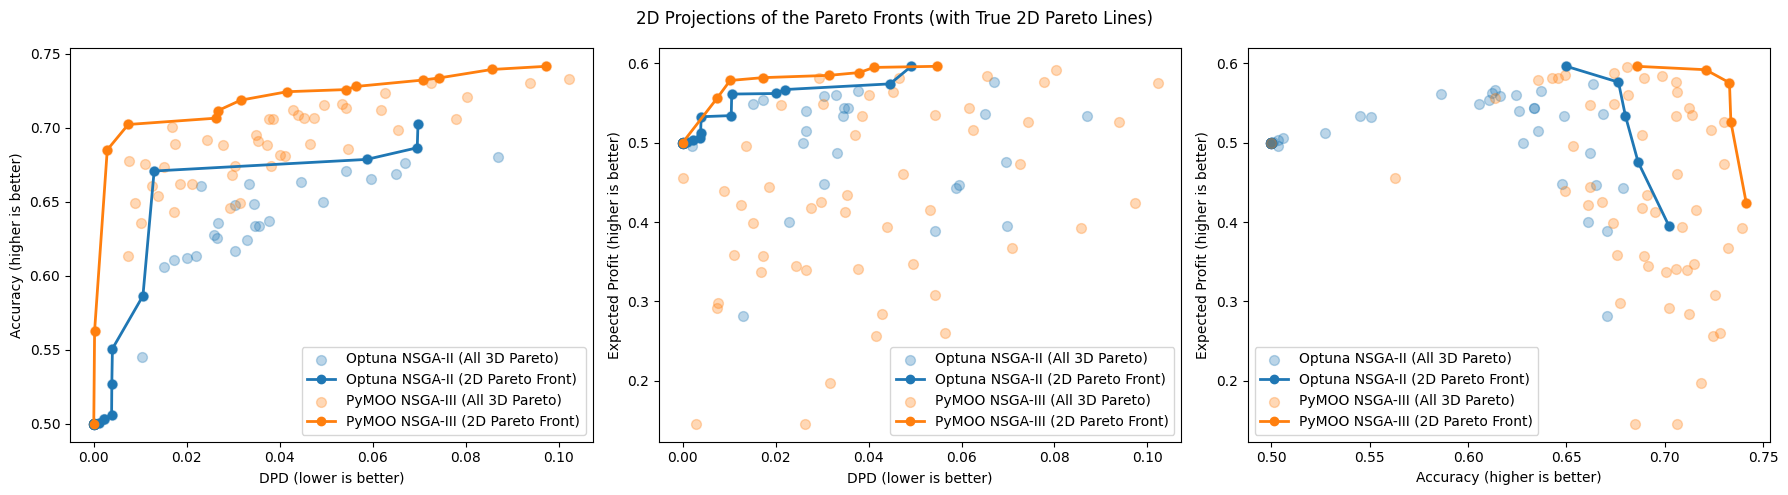

In [13]:
import os

# Combine results
df_all = pd.concat([df_optuna, df_pymoo], ignore_index=True)

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)
df_all.to_csv('data/moo_pareto_fronts.csv', index=False)

# 1. 3D Pareto Front
fig = px.scatter_3d(
    df_all, x='DPD', y='Accuracy', z='Profit',
    color='Algorithm', symbol='Algorithm',
    hover_data=['alpha_fair', 'threshold', 'fp_weight'],
    title='3D Pareto Front: Optuna NSGA-II vs PyMOO NSGA-III'
)
fig.update_layout(scene=dict(
    xaxis_title='DPD (Minimize)',
    yaxis_title='Accuracy (Maximize)',
    zaxis_title='Expected Profit (Maximize)'
))
fig.write_html("plots/3d_pareto_front.html")
fig.show()

# 2. Parallel Coordinates
fig2 = px.parallel_coordinates(
    df_all,
    dimensions=['alpha_fair', 'threshold', 'fp_weight', 'DPD', 'Accuracy', 'Profit'],
    color='Profit',
    title='Parallel Coordinates Plot of Pareto Solutions'
)
fig2.write_html("plots/parallel_coordinates.html")
fig2.show()

# 3. 2D Projections (with lines for true 2D Pareto front)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for alg in ['Optuna NSGA-II', 'PyMOO NSGA-III']:
    # Get all 3D Pareto solutions for the current algorithm
    subset = df_all[df_all['Algorithm'] == alg]

    # DPD vs Accuracy
    axes[0].scatter(subset['DPD'], subset['Accuracy'], label=f'{alg} (All 3D Pareto)', alpha=0.3, s=50)
    dpd_acc_idx = get_2d_pareto(subset['DPD'].values, subset['Accuracy'].values, min_x=True, min_y=False)
    dpd_acc_front = subset.iloc[dpd_acc_idx].sort_values(by='DPD')
    axes[0].plot(dpd_acc_front['DPD'], dpd_acc_front['Accuracy'], label=f'{alg} (2D Pareto Front)', marker='o', linestyle='-', linewidth=2, markersize=6)
    axes[0].set_xlabel('DPD (lower is better)'); axes[0].set_ylabel('Accuracy (higher is better)')

    # DPD vs Profit
    axes[1].scatter(subset['DPD'], subset['Profit'], label=f'{alg} (All 3D Pareto)', alpha=0.3, s=50)
    dpd_profit_idx = get_2d_pareto(subset['DPD'].values, subset['Profit'].values, min_x=True, min_y=False)
    dpd_profit_front = subset.iloc[dpd_profit_idx].sort_values(by='DPD')
    axes[1].plot(dpd_profit_front['DPD'], dpd_profit_front['Profit'], label=f'{alg} (2D Pareto Front)', marker='o', linestyle='-', linewidth=2, markersize=6)
    axes[1].set_xlabel('DPD (lower is better)'); axes[1].set_ylabel('Expected Profit (higher is better)')

    # Accuracy vs Profit
    axes[2].scatter(subset['Accuracy'], subset['Profit'], label=f'{alg} (All 3D Pareto)', alpha=0.3, s=50)
    acc_profit_idx = get_2d_pareto(subset['Accuracy'].values, subset['Profit'].values, min_x=False, min_y=False)
    acc_profit_front = subset.iloc[acc_profit_idx].sort_values(by='Accuracy')
    axes[2].plot(acc_profit_front['Accuracy'], acc_profit_front['Profit'], label=f'{alg} (2D Pareto Front)', marker='o', linestyle='-', linewidth=2, markersize=6)
    axes[2].set_xlabel('Accuracy (higher is better)'); axes[2].set_ylabel('Expected Profit (higher is better)')

for ax in axes:
    ax.legend()
plt.suptitle('2D Projections of the Pareto Fronts (with True 2D Pareto Lines)')
plt.tight_layout()
plt.savefig('plots/2d_projections_with_pareto_lines.png', dpi=150)
plt.show()